# **Regression** **Notebook**

In [31]:
# Import files module from Google Colab
# This is used to upload files from your local system to Colab
from google.colab import files

# Opens file upload dialog to upload zip file
files.upload()


Saving students_marks.zip to students_marks (1).zip


{'students_marks (1).zip': b'PK\x03\x04-\x00\x00\x08\x08\x00xb{[N\xb5\xcc\x9f\xff\xff\xff\xff\xff\xff\xff\xff\x14\x00\x14\x00Final_Marks_Data.csv\x01\x00\x10\x00\xba\xb4\x00\x00\x00\x00\x00\x00\xe59\x00\x00\x00\x00\x00\x00e}\xcd\xcev;\x8e\xd5\x1c\x89{8\x13$\x90\xde\xc1\xce\x7f2D\x02\x04\x03F\xcd\x1c\x95\xe8\x02\xb5\x80j\xa9\xabZ\x82\xbbg\xdbk-\xc7\xfbE:\xaaS\'_\xbel\'v\xec\xe5\x9f\xf8\xf9\xbb\xbf\xfd\xf3\xdf\xff\xf9/\x7f\xfb\xaf\xff\xe9\xdf\xfd\xfc\xdb\xbf\xfd\xed\xcf\x7f\xf9\xfb?\xfd\xe5\xbf\xfd\xf9\x8f\x7f\xfd\xaf\xfe\xcd\xcf\x7f\xfa\xcb\xdf\xfe\xfcO\x7f\xf9\xd3\xff\xfa\xe3\xbf\xfc\xf9\xaf\x7f\xfb\xa3\xfc\xf1\xaf\xff\xf1\x9f\xff\xf6\xc7?\xfe\xf7?\xfa\xf3\xfb\xcf\xea\xe7\xcf\xfe\xed_\xff\xfa\x0f\xff\xe3/\xff\xfb]\xf4\x8f\xbf\xfbo\xff\xf8O\x7f\x8e?,\xef\x1f\xfe\xbb?\xfd\xc3\xff\xfa\xbf\x7f\xd8G\xff\xef\x1f\xff\xf1\x1f\xff\xf9\x9f\xfe\xfa\xf3\x1f\xfe\xc1\xd6\xf9\xf7\xff\xe7O\xff\xfb\x8f\xff\xfc\xa7\x7f\xfa\x9f\x7fM\xd3\x9f\x7f\xf3/\xff\xc5\xdf\xbd\xffz~v\xffi\xcfO\x9b?\xeb\xa7\xfd\xac\x

In [32]:
# Import zipfile module to work with zip files
import zipfile

# Open the zip file in read mode
# Extract all contents of 'students_marks.zip' into current directory
with zipfile.ZipFile('students_marks.zip','r') as zip_ref:
  zip_ref.extractall()

In [33]:
# Import os module to interact with operating system
import os

# List all files and folders in the current directory
# Used to verify whether CSV file is extracted correctly
os.listdir()

['.config',
 'students_marks.zip',
 'student_marks_scaler.pkl',
 'student_marks_regression_model.pkl',
 'Final_Marks_Data.csv',
 'students_marks (1).zip',
 'spam.csv.xlsx',
 'sample_data']

In [34]:
# Import required libraries
import pandas as pd                 # For data handling
import numpy as np                  # For numerical operations
import matplotlib.pyplot as plt     # For visualization
import seaborn as sns               # For advanced plots


# **Load** **the** **Dataset**

The dataset is loaded from a CSV file into a DataFrame.

Encoding is specified to avoid text decoding errors.

In [35]:
# Load the dataset into a DataFrame
df = pd.read_csv('Final_Marks_Data.csv')

# Display first 5 rows
df.head()


,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


# **Exploratory** **Data** **Analysis** (**EDA**)

EDA helps to understand dataset structure and class distribution.

It identifies imbalance and verifies data correctness.

In [36]:
# Check dataset shape (rows, columns)
df.shape

(2000, 7)

In [37]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Student_ID                     2000 non-null   object
 1   Attendance (%)                 2000 non-null   int64 
 2   Internal Test 1 (out of 40)    2000 non-null   int64 
 3   Internal Test 2 (out of 40)    2000 non-null   int64 
 4   Assignment Score (out of 10)   2000 non-null   int64 
 5   Daily Study Hours              2000 non-null   int64 
 6   Final Exam Marks (out of 100)  2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [38]:
# Statistical summary of numerical columns
df.describe()

,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


# **Data** **Cleaning**

Data cleaning is used to detect missing or invalid values.

Clean data improves model accuracy and reliability.

In [39]:
# Check for missing values in each column
df.isnull().sum()


,0
Student_ID,0
Attendance (%),0
Internal Test 1 (out of 40),0
Internal Test 2 (out of 40),0
Assignment Score (out of 10),0
Daily Study Hours,0
Final Exam Marks (out of 100),0


# **Correlation** **Heatmap**

A correlation heatmap shows the relationship between numerical features.

In regression, it helps identify which features strongly influence the target variable.

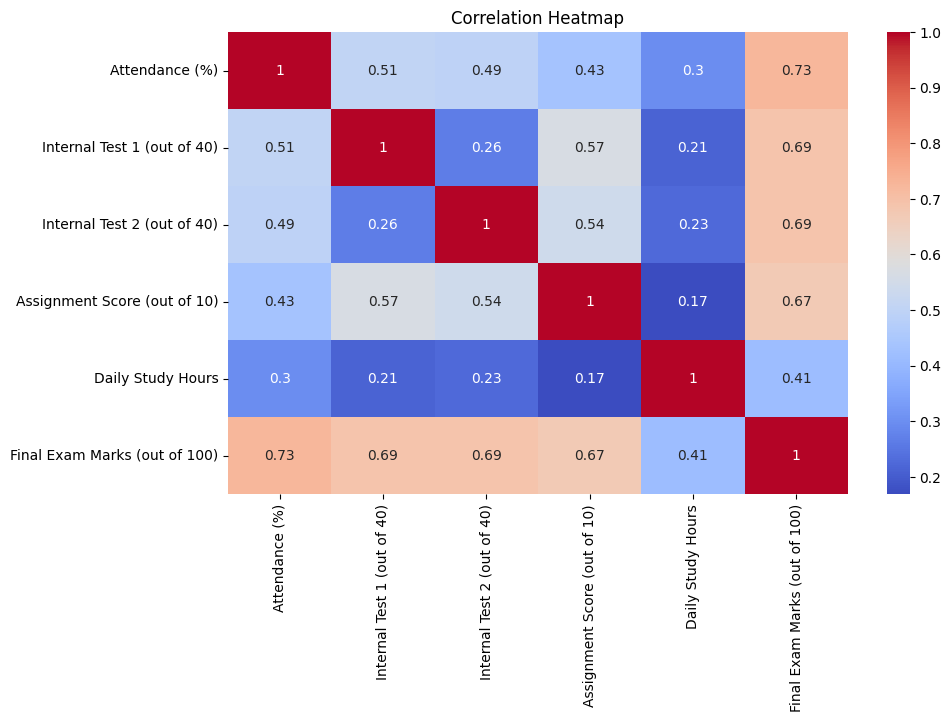

In [40]:
# Create correlation matrix
corr = df.drop('Student_ID', axis=1).corr()

# Plot heatmap to see relationship between features
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Feature Scaling**

Explanation:
Feature scaling converts features to the same scale.

This helps the regression model learn efficiently and improves performance.

In [41]:
# Define input features (X) and target variable (y)
X = df.drop(['Final Exam Marks (out of 100)', 'Student_ID'], axis=1)   # Independent variables
y = df['Final Exam Marks (out of 100)']                # Target variable

In [42]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale the input features
X_scaled = scaler.fit_transform(X)


## **Train–Test** **Split**

The dataset is divided into training and testing sets.

Training data is used to train the model, and testing data evaluates performance.

In [43]:
# Split dataset into training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# **Model** **Training** (**Regression** **Model**)

In this step, a Linear Regression model is trained using training data.

The model learns the relationship between input features and the target variable.

In [44]:
# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Create model object
model = LinearRegression()

# Train the model using training data
model.fit(X_train, y_train)


LinearRegression()

# **Prediction**

The trained model is used to predict values for unseen test data.

These predictions are later compared with actual values.

In [45]:
# Predict final exam marks on test data
y_pred = model.predict(X_test)


# **Regression** **Metrics**

Regression metrics measure how accurate the model predictions are.

Lower error values and higher R² score indicate better performance.

In [46]:
# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 3.674951300057304
MSE: 21.325405991113602
RMSE: 4.6179439138120335
R2 Score: 0.8297242264388041


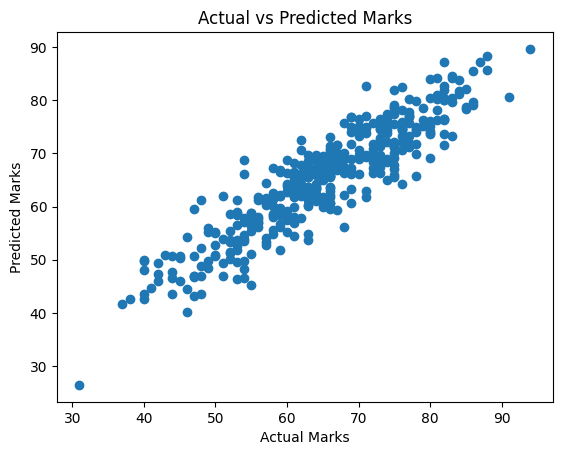

In [47]:
# Plot Actual vs Predicted values
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()


# **Overfitting** & **Underfitting** **Check**

This step checks whether the model performs similarly on training and testing data.

Large differences indicate overfitting or underfitting.

In [48]:
# Check training and testing score
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Training Score:", train_score)
print("Testing Score:", test_score)


Training Score: 0.8387214291420446
Testing Score: 0.8297242264388041


# **Inference**

In [49]:
import joblib

# Save trained regression model
joblib.dump(model, "student_marks_regression_model.pkl")

# Save scaler
joblib.dump(scaler, "student_marks_scaler.pkl")


['student_marks_scaler.pkl']

In [50]:
# Import joblib to load saved regression model and scaler
import joblib

# Load the trained regression model
loaded_model = joblib.load("/content/student_marks_regression_model.pkl")

# Load the scaler used during training
loaded_scaler = joblib.load("/content/student_marks_scaler.pkl")


In [51]:
# New student input data (same columns as training data)
new_student = {
    "Attendance (%)": 90,
    "Internal Test 1 (out of 40)": 30,
    "Internal Test 2 (out of 40)": 32,
    "Assignment Score (out of 10)": 9,
    "Daily Study Hours": 4
}


In [52]:
# Import pandas to create DataFrame
import pandas as pd

# Convert dictionary input into DataFrame
new_df = pd.DataFrame([new_student])


In [53]:
# Apply SAME scaling used during training
# IMPORTANT: use transform(), not fit_transform()
new_df_scaled = loaded_scaler.transform(new_df)


In [54]:
# Predict final exam marks using the trained model
predicted_marks = loaded_model.predict(new_df_scaled)

# Print the predicted marks
print("Predicted Final Exam Marks:", predicted_marks[0])


Predicted Final Exam Marks: 70.1436172995834
